# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/khadeja-qureshi/Machine-Learning-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Ranking Content Refresh Opportunities with Search Performance Signals

## Abstract

Content teams need a practical way to decide which existing webpages deserve refresh review first. This study uses page-level search-performance measurements from the FlyRank internship warehouse to test whether pre-decision signals can rank pages that later experience a greater-than-20% decline in average daily impressions. I compared a transparent CTR-and-visibility rule baseline with Logistic Regression and Random Forest using a client-grouped validation split and the same held-out pages for every method. Random Forest tied the baseline at Precision@20 with 0.600 and at Precision@50 with 0.560, while producing stronger full-ranking metrics with Average Precision of 0.446 versus 0.412 for the baseline. The result supports using the learned model as an additional human-review signal, not as proof that a page needs refreshing or that refreshing it would cause recovery.

In [9]:
from pathlib import Path
from urllib.request import urlopen
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

GITHUB_USERNAME = "khadeja-qureshi"
REPOSITORY_NAME = "Machine-Learning-Internship"
BRANCH = "main"

REPOSITORY_URL = (
    f"https://github.com/"
    f"{GITHUB_USERNAME}/{REPOSITORY_NAME}"
)

RAW_BASE_URL = (
    f"https://raw.githubusercontent.com/"
    f"{GITHUB_USERNAME}/{REPOSITORY_NAME}/"
    f"{BRANCH}/"
)

PAPER_URL = (
    f"https://{GITHUB_USERNAME}.github.io/"
    f"{REPOSITORY_NAME}/"
)

print("Repository:", REPOSITORY_URL)
print("Expected paper URL:", PAPER_URL)


def load_json(relative_path):
    """
    Load from the current filesystem when available.
    Otherwise load the committed file from GitHub.
    """
    local_path = Path(relative_path)

    if local_path.exists():
        with local_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            return json.load(file)

    remote_url = RAW_BASE_URL + relative_path

    with urlopen(remote_url) as response:
        return json.loads(
            response.read().decode("utf-8")
        )


metrics = load_json(
    "work/outputs/w05_model_metrics.json"
)

recommendation_records = load_json(
    "work/outputs/"
    "capstone_public_recommendations.json"
)

error_records = load_json(
    "work/outputs/"
    "capstone_public_error_cases.json"
)

comparison_df = pd.DataFrame(
    metrics["comparison_results"]
)

importance_df = pd.DataFrame(
    metrics["permutation_importance"]
)

recommendations_df = pd.DataFrame(
    recommendation_records
)

errors_df = pd.DataFrame(
    error_records
)

print("Metrics loaded.")
print("Comparison rows:", len(comparison_df))
print("Importance rows:", len(importance_df))
print("Recommendations:", len(recommendations_df))
print("Error cases:", len(errors_df))

Repository: https://github.com/khadeja-qureshi/Machine-Learning-Internship
Expected paper URL: https://khadeja-qureshi.github.io/Machine-Learning-Internship/
Metrics loaded.
Comparison rows: 3
Importance rows: 5
Recommendations: 20
Error cases: 3


## 1. Question

*The research question and the decision it supports.*

The research question is:

> Can a model using only pre-decision search-performance signals rank pages likely to experience a later decline more effectively than a transparent CTR-and-visibility baseline?

The operational decision is narrower than automatically rewriting pages. A content team has limited review capacity and needs to decide which existing pages should be inspected first.

The output is therefore a ranked decision-support queue. A high-ranked page should receive human review for query intent, SERP features, metadata quality, content freshness, seasonality, and technical issues before any refresh action is chosen.

In [10]:
question_receipt = pd.DataFrame(
    {
        "item": [
            "Lane",
            "Research task",
            "Decision supported",
            "Output",
            "Causal claim",
        ],
        "answer": [
            "Refresh / Content Opportunity Scoring",
            (
                "Rank pages by observed likelihood "
                "of later impression decline"
            ),
            (
                "Choose which existing pages "
                "a content team should review first"
            ),
            "Ranked human-review queue",
            (
                "None — the analysis does not show "
                "that refreshing causes recovery"
            ),
        ],
    }
)

display(question_receipt)

,item,answer
0,Lane,Refresh / Content Opportunity Scoring
1,Research task,Rank pages by observed likelihood of later imp...
2,Decision supported,Choose which existing pages a content team sho...
3,Output,Ranked human-review queue
4,Causal claim,None — the analysis does not show that refresh...


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


The analysis uses build `v20260703` of the FlyRank internship warehouse and the `fact_content_daily_performance` table.

The source grain is one row per report date, pseudonymized client, and pseudonymized content item. Daily records were aggregated into one row per client-content pair.

The feature window is March 1–15, 2026. The observed outcome window is March 16–31, 2026. June 2026 remains sealed and was not used for label design, feature selection, model selection, or validation.

Pages were retained when they had at least 10 observed days in each window, at least 100 feature-window impressions, and an average search position between 1 and 20.

Client and content identifiers were used only for grouping and row identity. URLs, domains, raw queries, GA4 fields, future-window measurements, label-derived fields, and existing product flags were excluded from model inputs.

In [11]:
data_summary = pd.DataFrame(
    {
        "item": [
            "Warehouse release",
            "Table",
            "March source rows",
            "March source clients",
            "March content items",
            "Eligible modeling rows",
            "Eligible modeling clients",
            "Training rows",
            "Validation rows",
            "Validation clients",
            "Feature window",
            "Outcome window",
            "Sealed month",
        ],
        "value": [
            metrics["warehouse_release"],
            metrics["warehouse_table"],
            f"{metrics['warehouse_rows']:,}",
            f"{metrics['warehouse_clients']:,}",
            f"{metrics['warehouse_content_items']:,}",
            f"{metrics['modeling_rows']:,}",
            f"{metrics['modeling_clients']:,}",
            f"{metrics['training_rows']:,}",
            f"{metrics['validation_rows']:,}",
            f"{metrics['validation_clients']:,}",
            metrics["feature_window"],
            metrics["outcome_window"],
            metrics["sealed_month_not_used"],
        ],
    }
)

display(data_summary)

assert metrics["sealed_month_not_used"] == "2026-06"
assert metrics["warehouse_partition"] == "2026-03"

print("Data-window checks passed.")

,item,value
0,Warehouse release,v20260703
1,Table,fact_content_daily_performance
2,March source rows,"9,841,378"
3,March source clients,55
4,March content items,"331,437"
5,Eligible modeling rows,"61,374"
6,Eligible modeling clients,36
7,Training rows,"39,619"
8,Validation rows,"21,755"
9,Validation clients,8


Data-window checks passed.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Observed label

A page receives a positive observed label when its average daily impressions during March 16–31 are more than 20% below its average during March 1–15.

This is an operational decline proxy. It is not a direct measurement of content quality and does not prove that a page needs a refresh.

### Features

The learned models use five March 1–15 inputs:

- log-transformed impressions;
- log-transformed clicks;
- CTR percentage;
- impression-weighted average search position;
- observed feature-window days.

Log transformations reduce the influence of extremely large impression and click values.

### Week-4 baseline

The transparent baseline compares each page's CTR with the median CTR for its position bucket. Its score gives 70% weight to relative CTR deficit and 30% weight to log-scaled impression volume.

### Models

Logistic Regression is the readable first model. Random Forest is the nonlinear challenger. Predicted probabilities are used as ranking scores rather than automatic class decisions.

### Validation design

Training and validation are grouped by `client_hash_id`. No validation client appears in training. Baseline reference values, model preprocessing, and model fitting use training clients only.

All three methods are evaluated on the same 21,755 validation pages using Precision@20, Precision@50, Average Precision, ROC AUC, and lift over the validation base rate.

### Leakage controls

Client and content identifiers are not features. Outcome fields, decline labels, future-window values, URLs, domains, query text, product flags, and GA4 fields are not used as model inputs.

In [12]:
FEATURES = metrics["features"]

forbidden_terms = [
    "outcome",
    "future",
    "declin",
    "label",
    "actual_change",
    "trend",
    "client",
    "content_hash",
    "query",
    "url",
    "domain",
]

for feature in FEATURES:
    assert not any(
        forbidden in feature.lower()
        for forbidden in forbidden_terms
    ), f"Potentially unsafe feature: {feature}"

methodology_summary = pd.DataFrame(
    {
        "component": [
            "Label",
            "Baseline",
            "Model 1",
            "Model 2",
            "Split",
            "Primary metrics",
            "Random seed",
        ],
        "design": [
            (
                "Later average daily impressions "
                "more than 20% below earlier average"
            ),
            (
                "70% CTR deficit + "
                "30% impression-volume strength"
            ),
            "Logistic Regression",
            "Random Forest",
            metrics["split_design"],
            "Precision@20 and Precision@50",
            metrics["random_state"],
        ],
    }
)

display(methodology_summary)

feature_table = pd.DataFrame(
    {
        "honest_feature": FEATURES
    }
)

display(feature_table)

print("Feature leakage check passed.")

,component,design
0,Label,Later average daily impressions more than 20% ...
1,Baseline,70% CTR deficit + 30% impression-volume strength
2,Model 1,Logistic Regression
3,Model 2,Random Forest
4,Split,80/20 grouped holdout by client_hash_id
5,Primary metrics,Precision@20 and Precision@50
6,Random seed,42


,honest_feature
0,log_impressions_first15
1,log_clicks_first15
2,ctr_pct_first15
3,avg_position_first15
4,active_days_first15


Feature leakage check passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

All methods were evaluated on the same 21,755 validation pages from held-out clients. The observed validation base rate was 0.333.

At Precision@20, the Week-4 baseline, Logistic Regression, and Random Forest all achieved 0.600, identifying 12 observed declines among the first 20 recommendations.

At Precision@50, Random Forest and the Week-4 baseline tied at 0.560, identifying 28 observed declines among the first 50 recommendations. Logistic Regression achieved 0.540.

Random Forest did not improve the two limited-queue precision metrics over the transparent baseline. It did produce stronger full-ranking metrics: Average Precision was 0.446 versus 0.412 for the baseline, and ROC AUC was 0.640 versus 0.602.

The result is a modest improvement across the full ranking rather than a decisive improvement at the top of the queue.

In [13]:
METHOD_ORDER = [
    "Week-4 baseline",
    "Logistic Regression",
    "Random Forest",
]

comparison_display = (
    comparison_df
    .set_index("method")
    .loc[METHOD_ORDER]
    .reset_index()
)

display(
    comparison_display.style.format(
        {
            "base_rate": "{:.3f}",
            "precision_at_20": "{:.3f}",
            "lift_at_20": "{:.2f}",
            "precision_at_50": "{:.3f}",
            "lift_at_50": "{:.2f}",
            "average_precision": "{:.3f}",
            "roc_auc": "{:.3f}",
        }
    )
)

baseline_result = (
    comparison_display[
        comparison_display["method"]
        == "Week-4 baseline"
    ]
    .iloc[0]
)

forest_result = (
    comparison_display[
        comparison_display["method"]
        == "Random Forest"
    ]
    .iloc[0]
)

assert (
    forest_result["precision_at_20"]
    == baseline_result["precision_at_20"]
)

assert (
    forest_result["precision_at_50"]
    == baseline_result["precision_at_50"]
)

print(
    "Confirmed: Random Forest tied the baseline "
    "at Precision@20 and Precision@50."
)

,method,validation_rows,base_rate,correct_at_20,precision_at_20,lift_at_20,correct_at_50,precision_at_50,lift_at_50,average_precision,roc_auc
0,Week-4 baseline,21755,0.333,12,0.600,1.80,28,0.560,1.68,0.412,0.602
1,Logistic Regression,21755,0.333,12,0.600,1.80,27,0.540,1.62,0.435,0.630
2,Random Forest,21755,0.333,12,0.600,1.80,28,0.560,1.68,0.446,0.640


Confirmed: Random Forest tied the baseline at Precision@20 and Precision@50.


## 5. Limitations

*What this work cannot claim.*


This analysis uses one grouped development split from one calendar month. Results may change under another client split or another time period.

The warehouse is an unbalanced client panel. Clients differ in history depth and measurement coverage.

The decline label compares two short adjacent windows. It may reflect seasonality, volatility, search-demand changes, technical events, competitor changes, or measurement variation rather than content quality.

Page-level CTR and average position hide variation across individual queries and search-result layouts. The model does not observe query intent, SERP features, branded-query share, content age, competitor activity, or technical page condition.

A selected page is a recommendation for human review, not proof that a refresh is required. The analysis does not reveal Google's algorithm and does not estimate the causal effect of refreshing content.

In [14]:
display(
    errors_df.style.format(
        {
            "model_score": "{:.3f}",
            "impressions": "{:,.0f}",
            "clicks": "{:,.0f}",
            "ctr_pct": "{:.3f}",
            "avg_position": "{:.2f}",
            "later_change_pct": "{:.1f}",
        }
    )
)

print(
    "The concrete errors show that similar "
    "feature-window signals can lead to very "
    "different later outcomes."
)

,error_group,rank,model_score,impressions,clicks,ctr_pct,avg_position,later_change_pct
0,false_positive_top_50,4,0.726,"14,588",6,0.041,8.21,-13.5
1,false_positive_top_50,8,0.724,"8,920",4,0.045,6.81,76.9
2,decline_outside_top_50,1873,0.603,342,0,0.000,5.50,-100.0


The concrete errors show that similar feature-window signals can lead to very different later outcomes.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final product is a public-safe top-20 review queue. It contains no client names, content identifiers, URLs, domains, or raw query text.

Every row receives the action label `REVIEW_FOR_REFRESH`.

The reason codes are:

- `LOW_CTR_HIGH_VISIBILITY`: substantial visibility with very low observed CTR;
- `LOW_CTR_STRONG_POSITION`: strong average search position with very low observed CTR;
- `MODEL_ELEVATED_DECLINE_RISK`: the learned model assigns elevated observed decline risk even when the simpler rule is less specific.

### Human action playbook

For each recommended page, the reviewer should:

1. Check whether low CTR is normal for the underlying query intent.
2. Check for featured snippets, knowledge panels, or other zero-click SERP features.
3. Review title and description alignment with search intent.
4. Inspect whether the content is outdated, incomplete, or poorly structured.
5. Check whether one unusual query dominates the page-level averages.
6. Check seasonality, temporary demand changes, and technical events.
7. Choose metadata review, content refresh, technical review, monitoring, or no action.

The queue prioritizes investigation. It does not prescribe an automatic rewrite.

In [15]:
PUBLIC_COLUMNS = [
    "rank",
    "model_score",
    "action_label",
    "reason_code",
    "confidence_note",
    "visibility_band",
    "position_band",
    "ctr_band",
]

assert list(recommendations_df.columns) == PUBLIC_COLUMNS

forbidden_public_columns = {
    "client_hash_id",
    "content_hash_id",
    "query_hash",
    "url",
    "domain",
}

assert forbidden_public_columns.isdisjoint(
    recommendations_df.columns
)

display(
    recommendations_df.style.format(
        {
            "model_score": "{:.3f}",
        }
    )
)

reason_summary = (
    recommendations_df[
        "reason_code"
    ]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="top_20_count")
)

display(reason_summary)

print("Public recommendation safety check passed.")

,rank,model_score,action_label,reason_code,confidence_note,visibility_band,position_band,ctr_band
0,1,0.733,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Higher model priority,very_high,page_1,very_low
1,2,0.730,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Higher model priority,very_high,page_1,very_low
2,3,0.727,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Higher model priority,very_high,page_1,very_low
3,4,0.726,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Higher model priority,very_high,page_1,very_low
4,5,0.725,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Higher model priority,very_high,page_1,very_low
5,6,0.724,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Moderate-high model priority,very_high,page_1,very_low
6,7,0.724,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Moderate-high model priority,very_high,page_1,very_low
7,8,0.724,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Moderate-high model priority,very_high,page_1,very_low
8,9,0.724,REVIEW_FOR_REFRESH,LOW_CTR_HIGH_VISIBILITY,Moderate-high model priority,very_high,page_1,very_low
9,10,0.723,REVIEW_FOR_REFRESH,MODEL_ELEVATED_DECLINE_RISK,Moderate-high model priority,very_high,page_1,low


,reason_code,top_20_count
0,LOW_CTR_HIGH_VISIBILITY,14
1,MODEL_ELEVATED_DECLINE_RISK,6


Public recommendation safety check passed.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The deployed paper uses three figures:

1. Precision@20 and Precision@50 for the baseline and both learned models.
2. Average Precision and ROC AUC across the full validation ranking.
3. Random Forest permutation importance.

Each figure presents one message and includes a plain-language caption in the deployed paper.

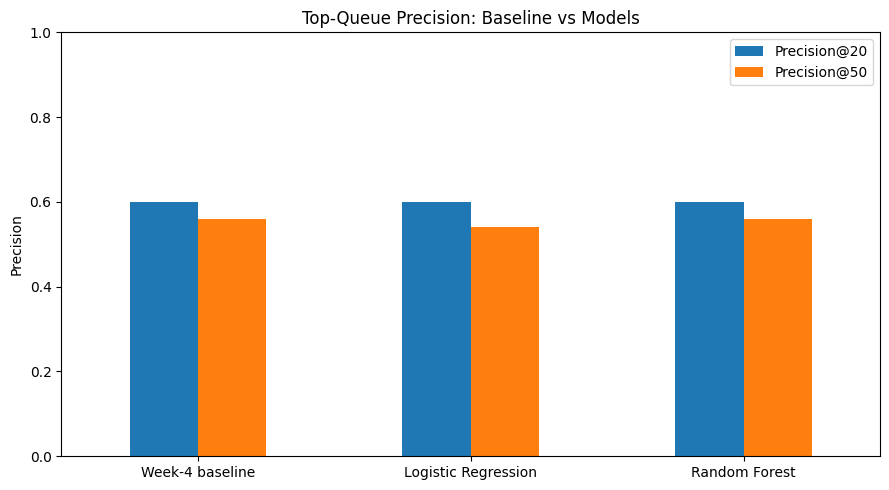

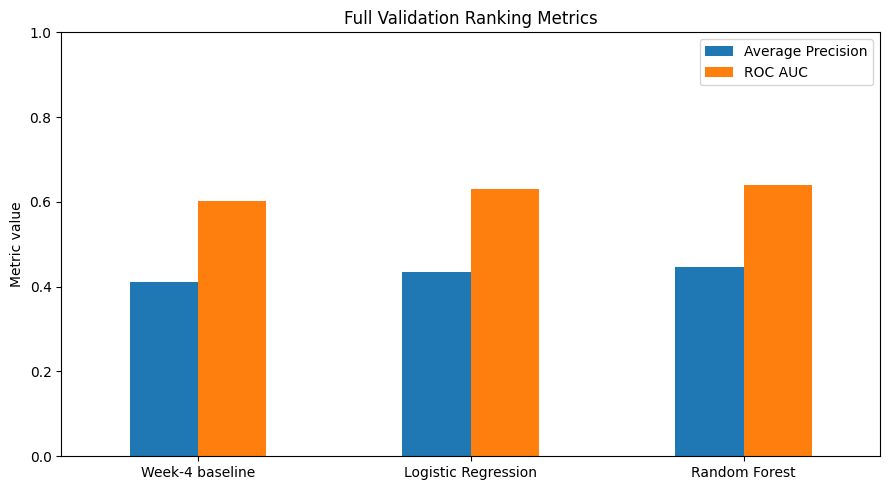

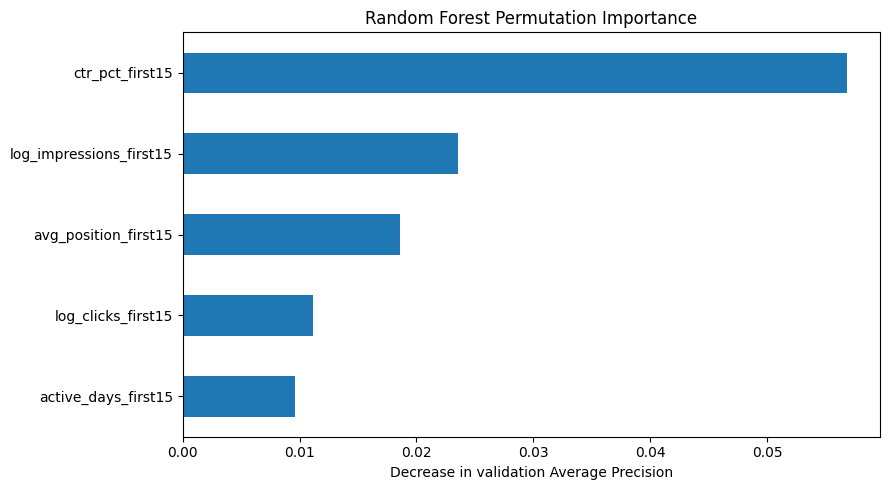

Saved: docs/figures/precision_comparison.png
Saved: docs/figures/full_ranking_metrics.png
Saved: docs/figures/permutation_importance.png


In [16]:
DOCS_DIR = Path("docs")
FIGURES_DIR = DOCS_DIR / "figures"
SUBMISSION_DIR = Path("submission")

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SUBMISSION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

plot_comparison = (
    comparison_df
    .set_index("method")
    .loc[METHOD_ORDER]
)

# Figure 1: queue precision
precision_plot = plot_comparison[
    [
        "precision_at_20",
        "precision_at_50",
    ]
].rename(
    columns={
        "precision_at_20": "Precision@20",
        "precision_at_50": "Precision@50",
    }
)

ax = precision_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Top-Queue Precision: Baseline vs Models"
)
ax.set_xlabel("")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

PRECISION_FIGURE = (
    FIGURES_DIR / "precision_comparison.png"
)

plt.savefig(
    PRECISION_FIGURE,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Figure 2: full-ranking metrics
full_ranking_plot = plot_comparison[
    [
        "average_precision",
        "roc_auc",
    ]
].rename(
    columns={
        "average_precision": "Average Precision",
        "roc_auc": "ROC AUC",
    }
)

ax = full_ranking_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title(
    "Full Validation Ranking Metrics"
)
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

FULL_RANKING_FIGURE = (
    FIGURES_DIR / "full_ranking_metrics.png"
)

plt.savefig(
    FULL_RANKING_FIGURE,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Figure 3: permutation importance
importance_plot = (
    importance_df
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

ax = importance_plot.plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)

ax.set_title(
    "Random Forest Permutation Importance"
)
ax.set_xlabel(
    "Decrease in validation Average Precision"
)
ax.set_ylabel("")

plt.tight_layout()

IMPORTANCE_FIGURE = (
    FIGURES_DIR / "permutation_importance.png"
)

plt.savefig(
    IMPORTANCE_FIGURE,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

for figure_path in [
    PRECISION_FIGURE,
    FULL_RANKING_FIGURE,
    IMPORTANCE_FIGURE,
]:
    assert figure_path.exists()
    print("Saved:", figure_path)

## 8. Reproducibility

The full modeling pipeline is contained in `work/notebooks/w05_model.ipynb`. It queries the March 2026 warehouse partition, constructs the feature and outcome windows, performs the client-grouped split, reproduces the Week-4 baseline, trains both learned models, evaluates them on the same held-out pages, calculates feature importance, and exports public-safe result receipts.

The modeling run uses random seed 42. The metrics receipt stores the Python, pandas, NumPy, DuckDB, and scikit-learn versions used for the reported results.

The public research paper links to the repository and the data-contract, baseline, modeling, and capstone notebooks.

In [17]:
reproducibility_links = pd.DataFrame(
    {
        "artifact": [
            "Repository",
            "Data contract notebook",
            "Baseline notebook",
            "Modeling notebook",
            "Capstone notebook",
        ],
        "url": [
            REPOSITORY_URL,
            (
                REPOSITORY_URL
                + "/blob/main/work/notebooks/"
                + "w03_data_contract.ipynb"
            ),
            (
                REPOSITORY_URL
                + "/blob/main/work/notebooks/"
                + "w04_baseline_score.ipynb"
            ),
            (
                REPOSITORY_URL
                + "/blob/main/work/notebooks/"
                + "w05_model.ipynb"
            ),
            (
                REPOSITORY_URL
                + "/blob/main/work/notebooks/"
                + "capstone.ipynb"
            ),
        ],
    }
)

display(reproducibility_links)

versions_df = pd.DataFrame(
    list(metrics["versions"].items()),
    columns=["library", "version"],
)

display(versions_df)

,artifact,url
0,Repository,https://github.com/khadeja-qureshi/Machine-Lea...
1,Data contract notebook,https://github.com/khadeja-qureshi/Machine-Lea...
2,Baseline notebook,https://github.com/khadeja-qureshi/Machine-Lea...
3,Modeling notebook,https://github.com/khadeja-qureshi/Machine-Lea...
4,Capstone notebook,https://github.com/khadeja-qureshi/Machine-Lea...


,library,version
0,python,3.12.13
1,pandas,2.2.2
2,numpy,2.0.2
3,duckdb,1.3.2
4,scikit_learn,1.6.1


## 9. Acknowledgments and data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

This project was completed as part of the FlyRank Machine Learning internship track.

In [18]:
DATA_CREDIT = (
    "Built on the FlyRank ML Internship dataset: "
    "https://flyrank.ai"
)

print(DATA_CREDIT)

assert "https://flyrank.ai" in DATA_CREDIT

Built on the FlyRank ML Internship dataset: https://flyrank.ai


## ML-12 — Five-minute demo outline

### 0:00–0:40 — Problem

A content team cannot inspect every existing webpage. My project asks whether five safe pre-decision search signals can rank pages for refresh review better than a transparent CTR-and-visibility rule.

### 0:40–1:30 — Data and honesty

I used the March 2026 partition of the FlyRank internship warehouse. March 1–15 supplies model inputs, March 16–31 supplies the observed decline label, and June remains sealed. Training and validation are grouped by client so validation clients are not present in training.

### 1:30–2:20 — Baseline and models

The Week-4 baseline gives 70% weight to CTR deficit and 30% to impression volume. I compared it with Logistic Regression and Random Forest using the same validation pages and metrics.

### 2:20–3:20 — Result

All three methods achieved Precision@20 of 0.600. Random Forest and the baseline tied at Precision@50 with 0.560. Random Forest performed better across the full ranking, with Average Precision of 0.446 versus 0.412 and ROC AUC of 0.640 versus 0.602.

### 3:20–4:10 — Interpretation

CTR, log-transformed impressions, and average search position were the three most important measured features. Error analysis showed that similar search signals can lead to very different outcomes, including one highly ranked page that later grew substantially.

### 4:10–5:00 — Product output and limitation

The final product is a public-safe ranked review queue with reason codes and a human action playbook. It supports prioritization but does not prove that a page needs refreshing or that a refresh would cause recovery.

## ML-12 — Social-post cut

I built a content-refresh review queue using 61,374 page-level records from the FlyRank ML Internship warehouse.

Using a client-grouped validation split, I compared a transparent CTR-and-visibility baseline with Logistic Regression and Random Forest. Random Forest tied the baseline at Precision@20 and Precision@50, but improved Average Precision from 0.412 to 0.446 and ROC AUC from 0.602 to 0.640.

The main lesson: complexity did not automatically improve the first recommendations. The model is most useful as an additional decision-support signal inside a human review process, not as an automatic refresh decision.

Research paper: [insert deployed URL]

## ML-12 — Employer-facing three-sentence summary

I built a reproducible page-level content opportunity scoring pipeline using more than 9.8 million daily search-performance records from the FlyRank internship warehouse. I designed leakage-safe feature and outcome windows, grouped validation by client, compared Logistic Regression and Random Forest with a transparent rule baseline, and converted the results into a public-safe ranked review queue. Random Forest improved full-ranking quality but tied the baseline at the limited top-20 and top-50 queue sizes, showing that I can report nuanced results rather than reward model complexity automatically.

In [19]:
comparison_for_html = comparison_display[
    [
        "method",
        "base_rate",
        "correct_at_20",
        "precision_at_20",
        "correct_at_50",
        "precision_at_50",
        "average_precision",
        "roc_auc",
    ]
].copy()

comparison_for_html.columns = [
    "Method",
    "Base rate",
    "Correct @20",
    "Precision@20",
    "Correct @50",
    "Precision@50",
    "Average Precision",
    "ROC AUC",
]

for column in [
    "Base rate",
    "Precision@20",
    "Precision@50",
    "Average Precision",
    "ROC AUC",
]:
    comparison_for_html[column] = (
        comparison_for_html[column]
        .map(lambda value: f"{value:.3f}")
    )

comparison_html = comparison_for_html.to_html(
    index=False,
    classes="data-table",
    border=0,
)

recommendations_for_html = (
    recommendations_df.copy()
)

recommendations_for_html.columns = [
    "Rank",
    "Model score",
    "Action",
    "Reason code",
    "Confidence",
    "Visibility",
    "Position",
    "CTR",
]

recommendations_html = (
    recommendations_for_html.to_html(
        index=False,
        classes="data-table",
        border=0,
    )
)

errors_for_html = errors_df.rename(
    columns={
        "error_group": "Error type",
        "rank": "Model rank",
        "model_score": "Model score",
        "impressions": "Impressions",
        "clicks": "Clicks",
        "ctr_pct": "CTR %",
        "avg_position": "Average position",
        "later_change_pct": "Later change %",
    }
)

errors_html = errors_for_html.to_html(
    index=False,
    classes="data-table",
    border=0,
)

In [20]:
top_features = (
    importance_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .head(3)["feature"]
    .tolist()
)

paper_html = f"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta
    name="viewport"
    content="width=device-width, initial-scale=1"
>
<title>
Ranking Content Refresh Opportunities with Search Performance Signals
</title>

<style>
:root {{
    --background: #f4f6f8;
    --surface: #ffffff;
    --text: #17202a;
    --muted: #5f6b76;
    --border: #dfe4ea;
    --accent: #234f7d;
    --width: 1080px;
}}

* {{
    box-sizing: border-box;
}}

body {{
    margin: 0;
    background: var(--background);
    color: var(--text);
    font-family:
        Inter, system-ui, -apple-system,
        BlinkMacSystemFont, "Segoe UI", sans-serif;
    line-height: 1.65;
}}

header {{
    padding: 64px 24px 48px;
    background: var(--surface);
    border-bottom: 1px solid var(--border);
}}

header div,
main {{
    width: min(var(--width), calc(100% - 40px));
    margin: 0 auto;
}}

h1 {{
    max-width: 900px;
    margin: 0 0 16px;
    font-size: clamp(2.2rem, 5vw, 4rem);
    line-height: 1.08;
}}

.subtitle {{
    max-width: 800px;
    color: var(--muted);
    font-size: 1.15rem;
}}

.badge {{
    display: inline-block;
    margin-bottom: 18px;
    padding: 6px 12px;
    border: 1px solid var(--border);
    border-radius: 999px;
    color: var(--accent);
    font-size: 0.85rem;
    font-weight: 700;
}}

main {{
    padding: 28px 0 72px;
}}

section {{
    margin: 26px 0;
    padding: 32px;
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 14px;
}}

h2 {{
    margin-top: 0;
}}

h3 {{
    margin-top: 30px;
}}

.callout {{
    margin: 24px 0;
    padding: 18px 20px;
    border-left: 4px solid var(--accent);
    background: #f1f6fb;
}}

.summary-grid {{
    display: grid;
    grid-template-columns:
        repeat(auto-fit, minmax(180px, 1fr));
    gap: 14px;
    margin: 24px 0;
}}

.metric {{
    padding: 18px;
    border: 1px solid var(--border);
    border-radius: 10px;
}}

.metric strong {{
    display: block;
    font-size: 1.65rem;
}}

.metric span {{
    color: var(--muted);
}}

figure {{
    margin: 32px 0;
}}

figure img {{
    width: 100%;
    border: 1px solid var(--border);
    border-radius: 10px;
}}

figcaption {{
    margin-top: 10px;
    color: var(--muted);
    font-size: 0.94rem;
}}

.table-wrapper {{
    overflow-x: auto;
}}

.data-table {{
    width: 100%;
    border-collapse: collapse;
    font-size: 0.92rem;
}}

.data-table th,
.data-table td {{
    padding: 10px 12px;
    border-bottom: 1px solid var(--border);
    text-align: left;
    vertical-align: top;
}}

.data-table th {{
    background: #f1f4f7;
}}

a {{
    color: var(--accent);
}}

footer {{
    padding: 28px 20px 48px;
    color: var(--muted);
    text-align: center;
}}

@media (max-width: 650px) {{
    section {{
        padding: 21px;
    }}
}}
</style>
</head>

<body>
<header>
<div>
    <div class="badge">
        FlyRank Machine Learning Capstone
    </div>

    <h1>
        Ranking Content Refresh Opportunities
        with Search Performance Signals
    </h1>

    <p class="subtitle">
        A client-grouped comparison of a transparent
        CTR-and-visibility baseline, Logistic
        Regression, and Random Forest.
    </p>
</div>
</header>

<main>
<section id="abstract">
<h2>Abstract</h2>

<p>
Content teams need a practical way to decide which
existing webpages deserve refresh review first.
This study uses page-level search-performance
measurements from the FlyRank internship warehouse
to test whether pre-decision signals can rank pages
that later experience a greater-than-20% decline in
average daily impressions. I compared a transparent
CTR-and-visibility rule baseline with Logistic
Regression and Random Forest using a client-grouped
validation split and the same held-out pages for
every method. Random Forest tied the baseline at
Precision@20 with 0.600 and at Precision@50 with
0.560, while producing stronger full-ranking
metrics with Average Precision of 0.446 versus
0.412 for the baseline. The result supports using
the learned model as an additional human-review
signal, not as proof that a page needs refreshing
or that refreshing it would cause recovery.
</p>
</section>

<section id="introduction">
<h2>Introduction and problem statement</h2>

<p>
A content team cannot manually inspect every
existing webpage. The practical decision is which
pages should be inspected first when review
capacity is limited.
</p>

<p>
Search declines may reflect outdated content,
changing demand, query intent, competitors, SERP
features, technical issues, or measurement
variation. A low-performing page should therefore
not automatically be rewritten.
</p>

<div class="callout">
<strong>Decision supported:</strong>
prioritize existing pages for human refresh review,
with reason codes and an action playbook.
</div>
</section>

<section id="data">
<h2>Data</h2>

<p>
The study uses build
<strong>{metrics["warehouse_release"]}</strong>
of the FlyRank internship warehouse and the
<code>{metrics["warehouse_table"]}</code> table.
</p>

<div class="summary-grid">
<div class="metric">
<strong>{metrics["warehouse_rows"]:,}</strong>
<span>March daily source rows</span>
</div>

<div class="metric">
<strong>{metrics["modeling_rows"]:,}</strong>
<span>eligible page-level rows</span>
</div>

<div class="metric">
<strong>{metrics["validation_rows"]:,}</strong>
<span>validation pages</span>
</div>

<div class="metric">
<strong>{metrics["validation_clients"]}</strong>
<span>held-out clients</span>
</div>
</div>

<p>
The source grain is one report date, pseudonymized
client, and pseudonymized content item. Daily
records were aggregated into one row per
client-content pair.
</p>

<p>
March 1–15, 2026 supplies model inputs.
March 16–31 supplies only the observed outcome.
June 2026 remains sealed.
</p>

<p>
URLs, domains, raw queries, GA4 fields, identifiers,
future-window measurements, product flags, and
label-derived inputs were excluded from the model.
</p>
</section>

<section id="methodology">
<h2>Methodology</h2>

<h3>Observed label</h3>
<p>
A page receives a positive observed label when its
later average daily impressions are more than 20%
below its feature-window average.
</p>

<h3>Features</h3>
<ul>
<li>Log-transformed impressions</li>
<li>Log-transformed clicks</li>
<li>CTR percentage</li>
<li>Average search position</li>
<li>Observed feature-window days</li>
</ul>

<h3>Baseline and models</h3>
<p>
The baseline gives 70% weight to CTR deficit and
30% to log-scaled impression volume. Logistic
Regression is the readable model, while Random
Forest is the nonlinear challenger. Probabilities
are used as ranking scores.
</p>

<h3>Validation</h3>
<p>
Training and validation are grouped by client.
No validation client appears in training.
All methods use the same validation pages, metrics,
and tie-breaking process.
</p>

<h3>Leakage controls</h3>
<p>
Baseline reference values and model preprocessing
are fitted on training clients only. Identifiers,
future fields, outcome fields, labels, URLs, domains,
queries, and product flags are not model inputs.
</p>
</section>

<section id="results">
<h2>Results</h2>

<div class="table-wrapper">
{comparison_html}
</div>

<figure>
<img
    src="figures/precision_comparison.png"
    alt="Precision at 20 and 50 by method"
>
<figcaption>
All three methods tied at Precision@20. Random
Forest and the baseline also tied at Precision@50.
</figcaption>
</figure>

<figure>
<img
    src="figures/full_ranking_metrics.png"
    alt="Full ranking metrics by method"
>
<figcaption>
Random Forest produced stronger Average Precision
and ROC AUC across the full validation ranking.
</figcaption>
</figure>

<p>
Random Forest did not improve the two limited-queue
precision metrics over the Week-4 baseline.
It improved Average Precision from 0.412 to 0.446
and ROC AUC from 0.602 to 0.640.
</p>

<p>
The result is a modest full-ranking improvement,
not a decisive improvement at the top of the queue.
</p>
</section>

<section id="limitations">
<h2>Limitations and honest framing</h2>

<ul>
<li>
The study uses one grouped development split from
one calendar month.
</li>
<li>
Clients differ in available history and measurement
coverage.
</li>
<li>
The short-window label may reflect seasonality,
volatility, changing demand, or technical events.
</li>
<li>
Page-level averages hide query-level and SERP-level
variation.
</li>
<li>
The model does not observe content age, query
intent, competitor actions, or technical condition.
</li>
<li>
A selected page is a review recommendation, not
proof that a refresh is necessary.
</li>
</ul>

<p>
The study does not reveal Google's ranking
algorithm and does not estimate the causal effect
of refreshing content.
</p>

<h3>Concrete error cases</h3>
<div class="table-wrapper">
{errors_html}
</div>
</section>

<section id="recommendations">
<h2>Ranked recommendations</h2>

<p>
The following public-safe queue excludes client
names, page identifiers, URLs, domains, and queries.
</p>

<div class="table-wrapper">
{recommendations_html}
</div>

<h3>Action playbook</h3>
<ol>
<li>Check query intent and normal CTR expectations.</li>
<li>Check zero-click and other SERP features.</li>
<li>Review metadata alignment.</li>
<li>Inspect content freshness and completeness.</li>
<li>Check whether one query dominates the averages.</li>
<li>Check seasonality and technical events.</li>
<li>
Choose refresh, metadata review, technical review,
monitoring, or no action.
</li>
</ol>
</section>

<section id="interpretation">
<h2>Model interpretation</h2>

<figure>
<img
    src="figures/permutation_importance.png"
    alt="Random Forest permutation importance"
>
<figcaption>
Permutation importance measures model reliance,
not causal influence.
</figcaption>
</figure>

<p>
The top three measured features were
<code>{top_features[0]}</code>,
<code>{top_features[1]}</code>, and
<code>{top_features[2]}</code>.
</p>
</section>

<section id="reproducibility">
<h2>Reproducibility</h2>

<p>
The final modeling run used random seed
<strong>{metrics["random_state"]}</strong>.
The metrics receipt records the software versions
used for the result.
</p>

<ul>
<li>
<a href="{REPOSITORY_URL}">
Project repository
</a>
</li>
<li>
<a href="{REPOSITORY_URL}/blob/main/work/notebooks/w03_data_contract.ipynb">
Data contract notebook
</a>
</li>
<li>
<a href="{REPOSITORY_URL}/blob/main/work/notebooks/w04_baseline_score.ipynb">
Baseline notebook
</a>
</li>
<li>
<a href="{REPOSITORY_URL}/blob/main/work/notebooks/w05_model.ipynb">
Modeling notebook
</a>
</li>
<li>
<a href="{REPOSITORY_URL}/blob/main/work/notebooks/capstone.ipynb">
Capstone notebook
</a>
</li>
</ul>
</section>

<section id="acknowledgments">
<h2>Acknowledgments and data credit</h2>

<p>
Built on the
<a href="https://flyrank.ai">
FlyRank ML Internship dataset
</a>.
</p>

<p>
Completed as part of the FlyRank Machine Learning
internship track.
</p>
</section>
</main>

<footer>
Refresh / Content Opportunity Scoring capstone
</footer>
</body>
</html>
"""

INDEX_PATH = DOCS_DIR / "index.html"

INDEX_PATH.write_text(
    paper_html,
    encoding="utf-8",
)

(DOCS_DIR / ".nojekyll").write_text(
    "",
    encoding="utf-8",
)

print("Paper created:", INDEX_PATH)

Paper created: docs/index.html


In [21]:
PAPER_URL_PATH = (
    SUBMISSION_DIR / "paper_url.txt"
)

PAPER_URL_PATH.write_text(
    PAPER_URL + "\n",
    encoding="utf-8",
)

paper_url_lines = (
    PAPER_URL_PATH
    .read_text(encoding="utf-8")
    .splitlines()
)

assert len(paper_url_lines) == 1
assert paper_url_lines[0] == PAPER_URL

print("Created:", PAPER_URL_PATH)
print("Paper URL:", PAPER_URL)

Created: submission/paper_url.txt
Paper URL: https://khadeja-qureshi.github.io/Machine-Learning-Internship/


In [22]:
generated_html = INDEX_PATH.read_text(
    encoding="utf-8"
)

forbidden_public_text = [
    "client_hash_id",
    "content_hash_id",
    "query_hash",
    "HF_TOKEN",
    "safe_token",
]

for forbidden_text in forbidden_public_text:
    assert forbidden_text not in generated_html, (
        f"Forbidden public text found: "
        f"{forbidden_text}"
    )

required_sections = [
    "Abstract",
    "Introduction and problem statement",
    "Data",
    "Methodology",
    "Results",
    "Limitations and honest framing",
    "Ranked recommendations",
    "Reproducibility",
    "Acknowledgments and data credit",
]

for section_name in required_sections:
    assert section_name in generated_html, (
        f"Missing paper section: {section_name}"
    )

assert "https://flyrank.ai" in generated_html
assert INDEX_PATH.exists()
assert PRECISION_FIGURE.exists()
assert FULL_RANKING_FIGURE.exists()
assert IMPORTANCE_FIGURE.exists()
assert PAPER_URL_PATH.exists()

print("Public-safety and completeness checks passed.")

Public-safety and completeness checks passed.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
